# 03b-06 - Mesh and Surface Model

The cloud of 03b-05 is points, more than a hundred per square metre, with gaps where no photograph saw the ground and stray points where the depth maps disagreed. Two boxes of the lecture's pipeline turn those points into surfaces. The mesh box joins them into triangles, so that the model has a skin that can carry a photograph's colours and hides whatever lies behind it, which is what the orthomosaic of 03b-07 will need. The surface model box lays a grid over the ground and keeps one height per cell, the raster 03-07 subtracted the terrain from; and the terrain model is that same grid with everything standing on the ground taken away and the ground beneath it filled in. The software, which here means OpenDroneMap with its meshing and its digital elevation model steps, made all three, and the kit carries each cut to the pinned window.

We make all three by hand beside them. The mesh is a Delaunay triangulation of the window's points thinned to one per quarter metre, which is the two and a half dimensional mesh a nadir block deserves, set beside the software's triangles in the same window. The surface model is the highest point in every cell, gaps and all, and the difference to the software's shows where one stray point per cell matters and what filtering and filling buy. The terrain model is a progressive morphological opening with the software's own parameters, and reading it beside the software's terrain is where we find the limit of every such filter: it removes what is narrower than its largest window and keeps what is wider, roof included. Hillshades of both and their difference, the height of things, close the notebook.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import numpy as np
import rasterio
from scipy import ndimage as ndi
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
choices = flight["p03b"]
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, {flight['n_photos']} photographs, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs, processed with OpenDroneMap


## The window's points

Everything in this notebook lives in the map frame of 03b-04, the products' coordinate system minus the offset that `data/flight.json` names, and everything is cut to the pinned window. The cloud file stores its points as offsets from the window's centre, so adding the centre back puts them in the map frame; the two models are GeoTIFFs in the products' coordinate system with the offset not subtracted, so subtracting it from their bounds puts their grid in the same frame. The cell reads all three, prints their extents against each other so that the frames are seen to agree before anything is computed on them, and draws the cloud once more, by height, with the grid's outline on it:

356,691 points in the window, 203.8 per square metre   reference 356,691, 203.8
the points run from 114.2 to 164.2 m east and -15.8 to 19.2 m north of the map frame's origin
the models' grid runs from 114.2 to 164.2 m east and -15.8 to 19.2 m north, 1000 by 700 cells of 5 cm in EPSG:32618   reference 1000 by 700 cells of 5 cm in EPSG:32618
the surface model runs from -89.72 to -69.64 m and the terrain model from -89.83 to -73.84 m   reference -89.72 to -69.64 and -89.83 to -73.84
the cloud's heights run from -89.88 to -69.56 m   reference -89.88 to -69.56


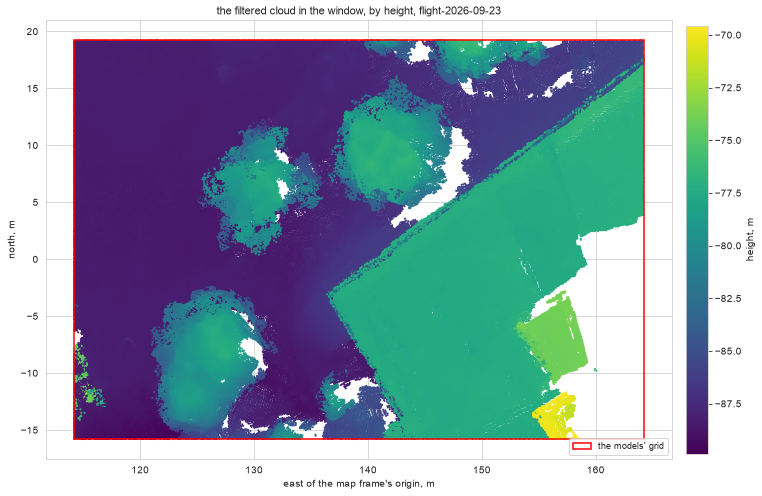

In [2]:
dense = np.load("data/dense_window.npz")
centre_local = np.array([float(dense["centre_local"][0]), float(dense["centre_local"][1]), 0.0])
xyz = dense["xyz"].astype(float) + centre_local                                  # the map frame
half_w, half_h = [float(v) for v in dense["half_m"]]; area = 4 * half_w * half_h
with rasterio.open("data/dsm_window.tif") as src:
    dsm = src.read(1, masked=True).filled(np.nan); dsm_transform = src.transform; cell_m = float(src.res[0]); dsm_crs = src.crs
with rasterio.open("data/dtm_window.tif") as src:
    dtm = src.read(1, masked=True).filled(np.nan)
offset = np.asarray(choices["offset"], dtype=float)
rows, cols = dsm.shape
bounds_local = (dsm_transform.c - offset[0], dsm_transform.f + rows * dsm_transform.e - offset[1],
                dsm_transform.c + cols * dsm_transform.a - offset[0], dsm_transform.f - offset[1])     # minx, miny, maxx, maxy in the map frame
extent = (bounds_local[0], bounds_local[2], bounds_local[1], bounds_local[3])                           # what imshow wants
d = reference["dem"]
print(f"{len(xyz):,} points in the window, {len(xyz) / area:.1f} per square metre   reference {reference['dense']['points']:,}, {reference['dense']['per_m2']}")
print(f"the points run from {xyz[:, 0].min():.1f} to {xyz[:, 0].max():.1f} m east and {xyz[:, 1].min():.1f} to {xyz[:, 1].max():.1f} m north of the map frame's origin")
print(f"the models' grid runs from {bounds_local[0]:.1f} to {bounds_local[2]:.1f} m east and {bounds_local[1]:.1f} to {bounds_local[3]:.1f} m north, {cols} by {rows} cells of {cell_m * 100:.0f} cm in {dsm_crs}   reference {d['window'][0]} by {d['window'][1]} cells of {d['res_m'] * 100:.0f} cm in {d['crs']}")
print(f"the surface model runs from {np.nanmin(dsm):.2f} to {np.nanmax(dsm):.2f} m and the terrain model from {np.nanmin(dtm):.2f} to {np.nanmax(dtm):.2f} m   reference {d['dsm_range_m'][0]} to {d['dsm_range_m'][1]} and {d['dtm_range_m'][0]} to {d['dtm_range_m'][1]}")
print(f"the cloud's heights run from {xyz[:, 2].min():.2f} to {xyz[:, 2].max():.2f} m   reference {reference['dense']['z_range_m'][0]} to {reference['dense']['z_range_m'][1]}")

fig, ax = plt.subplots(figsize=(11, 7))
shown = ax.scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], s=1, cmap="viridis")
fig.colorbar(shown, ax=ax, fraction=0.03, pad=0.02, label="height, m")
ax.add_patch(plt.Rectangle((bounds_local[0], bounds_local[1]), bounds_local[2] - bounds_local[0], bounds_local[3] - bounds_local[1], facecolor="none", edgecolor="red", linewidth=1.5, label="the models' grid"))
ax.set_aspect("equal"); ax.set_xlabel("east of the map frame's origin, m"); ax.set_ylabel("north, m"); ax.legend(loc="lower right", fontsize=9)
ax.set_title(f"the filtered cloud in the window, by height, {flight['label']}", fontsize=11)
fig.tight_layout()

Five lines of bookkeeping, and the second and third are the ones to compare: the points and the grid should span the same fifty by thirty five metres in the same frame, to within a cell, or nothing below would line up. The fourth line is worth a pause. The surface model's range is the lawn to the top of the tallest thing, and the terrain model's should be the lawn to the lawn's own rise across the window, a metre or two. If the terrain model instead reaches as high as a roof stands, the terrain model has kept a roof, and the fourth section of this notebook finds out why. The last line is the cloud's own range of heights, which the surface model's range should nearly equal, since the surface model is made from these points.

## Points to a surface: a mesh by hand

A mesh is the cloud joined into triangles. For a block flown straight down there is a shortcut that the software takes and that we take too. Seen from above, no point of the window hides under another, roofs and crowns have only tops, so the triangles can be found in the plan alone and the heights attached afterwards; that is a two and a half dimensional mesh, and the software's option is named after it. The triangulation in the plan is Delaunay's, the one whose triangles are as fat as the points allow, and `scipy.spatial.Delaunay` does it in one call. The cloud is thinned first to one point per quarter metre, by an integer cell number per point and `np.unique`, which keeps the first point of every cell, because a triangle per point at a hundred points per square metre would be more triangles than the window has pixels to draw. The software's mesh in the same window sits beside it, and its triangle count against ours is the point of the section:

by hand        25,985 points after thinning, 51,942 triangles   reference 25,985 points, 51,942 triangles
the software   5,674 vertices and 11,068 triangles touch the window, of 196,002 vertices and 391,224 triangles in the whole mesh   reference 5,674 and 11,068 of 196,002 and 391,224
that is 30 triangles per square metre by hand against 6.3 from the software, 4.7 times as many


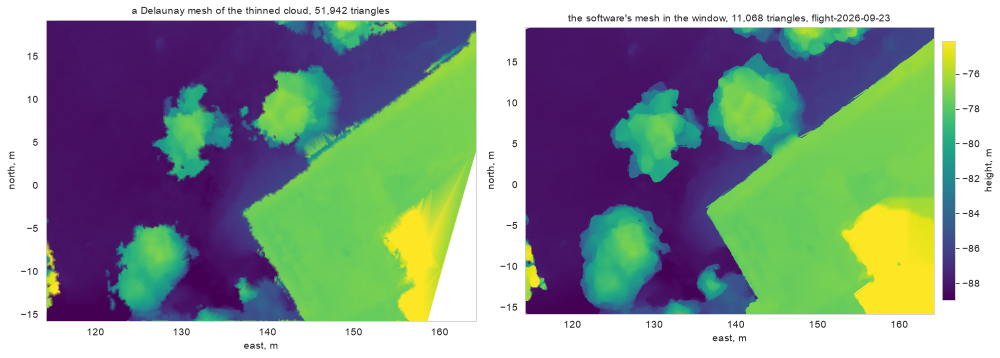

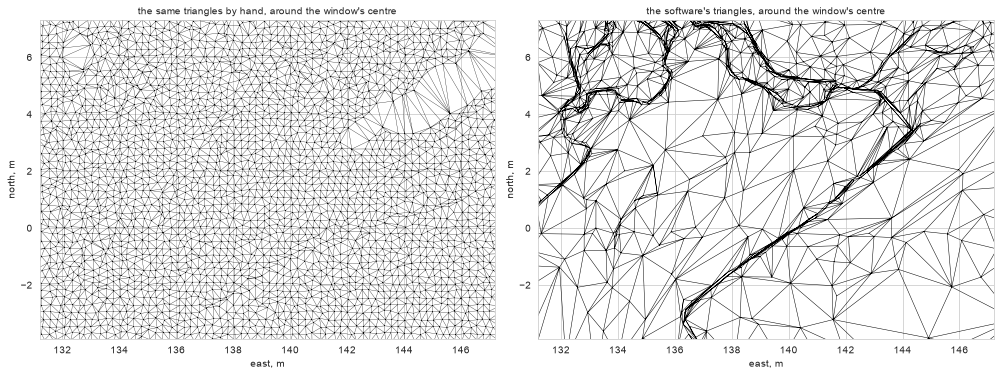

In [3]:
cell_ids = np.floor(xyz[:, :2] / 0.25).astype(int)                              # a quarter metre cell number in x and in y
_, first = np.unique(cell_ids[:, 0] * 100000 + cell_ids[:, 1], return_index=True)
thin = xyz[first]                                                                # the first point of every occupied cell
tri = Delaunay(thin[:, :2])                                                      # triangles in the plan; the heights ride along
mesh = np.load("data/mesh_window.npz")
vertices = mesh["vertices"].astype(float) + centre_local; faces = mesh["faces"]
m = reference["mesh"]
print(f"by hand        {len(thin):,} points after thinning, {len(tri.simplices):,} triangles   reference {m['delaunay']['points']:,} points, {m['delaunay']['faces']:,} triangles")
print(f"the software   {len(vertices):,} vertices and {len(faces):,} triangles touch the window, of {int(mesh['n_vertices_total']):,} vertices and {int(mesh['n_faces_total']):,} triangles in the whole mesh   reference {m['vertices']:,} and {m['faces']:,} of {m['vertices_total']:,} and {m['faces_total']:,}")
print(f"that is {len(tri.simplices) / area:.0f} triangles per square metre by hand against {len(faces) / area:.1f} from the software, {len(tri.simplices) / len(faces):.1f} times as many")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
lo, hi = np.percentile(xyz[:, 2], 1), np.percentile(xyz[:, 2], 99)
axes[0].tripcolor(thin[:, 0], thin[:, 1], tri.simplices, thin[:, 2], shading="gouraud", cmap="viridis", vmin=lo, vmax=hi)
axes[0].set_title(f"a Delaunay mesh of the thinned cloud, {len(tri.simplices):,} triangles", fontsize=10)
shown = axes[1].tripcolor(vertices[:, 0], vertices[:, 1], faces, vertices[:, 2], shading="gouraud", cmap="viridis", vmin=lo, vmax=hi)
axes[1].set_title(f"the software's mesh in the window, {len(faces):,} triangles, {flight['label']}", fontsize=10)
fig.colorbar(shown, ax=axes[1], fraction=0.03, pad=0.02, label="height, m")
for ax in axes:
    ax.set_xlim(bounds_local[0], bounds_local[2]); ax.set_ylim(bounds_local[1], bounds_local[3]); ax.set_aspect("equal"); ax.grid(False)
    ax.set_xlabel("east, m"); ax.set_ylabel("north, m")
fig.tight_layout()

zoom_w, zoom_h = 8.0, 5.6                                                        # a piece around the window's centre, where the triangles can be seen
cx, cy = choices["window"]["centre_local"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].triplot(thin[:, 0], thin[:, 1], tri.simplices, linewidth=0.3, color="black")
axes[0].set_title("the same triangles by hand, around the window's centre", fontsize=10)
axes[1].triplot(vertices[:, 0], vertices[:, 1], faces, linewidth=0.5, color="black")
axes[1].set_title("the software's triangles, around the window's centre", fontsize=10)
for ax in axes:
    ax.set_xlim(cx - zoom_w, cx + zoom_w); ax.set_ylim(cy - zoom_h, cy + zoom_h); ax.set_aspect("equal")
    ax.set_xlabel("east, m"); ax.set_ylabel("north, m")
fig.tight_layout()

The first line is our mesh, one point per quarter metre and about two triangles per point, which is what Delaunay gives on any spread of points. The second is the software's in the same window, and the ratio on the third line is the lesson: the software's mesh has far fewer triangles for the same ground. It did not thin the cloud to a grid as we did; it built a fine mesh and then simplified it to a budget of faces for the whole model, removing triangles wherever the surface is flat and keeping them wherever it bends. The two pictures by height look nearly the same at this scale, because both meshes carry the same heights. The zoom is where they differ. Ours is an even lattice of small triangles that also bridges every gap in the cloud with long thin ones, since Delaunay has no idea which gaps are real; the software's has large triangles on the lawn and the roof and a crowd of small ones along the roof's edge and around every crown, where a triangle would otherwise have to cut through the surface.

## Points to a grid: the surface model by hand

The surface model is the simplest product in the pipeline to describe. Lay a grid over the ground, and in every cell keep the highest point. That is the recipe of a digital surface model from any point cloud, lidar or photogrammetry, and `np.maximum.at` does it in one line once each point has a row and a column. The grid we lay is the software's own, read from the file's transform and shifted into the map frame, at the software's own cell size, so that the two rasters can be subtracted cell for cell. Cells with no point stay empty, and the second half of the cell fills them the simplest way, from the nearest cell that has a value:

38.2% of the cells hold at least one point, 25 points in the fullest   reference 38.2%
on those cells, against the software's surface model: median absolute difference 0.028 m, 95th percentile 2.690 m, RMS 1.483 m   reference 0.028, 2.69, 1.483
8.8% of the filled cells differ from the software's by more than half a metre, and they carry 99.7% of the squared difference
with the gaps filled from the nearest cell: median absolute difference 0.027 m, RMS 1.271 m over every cell


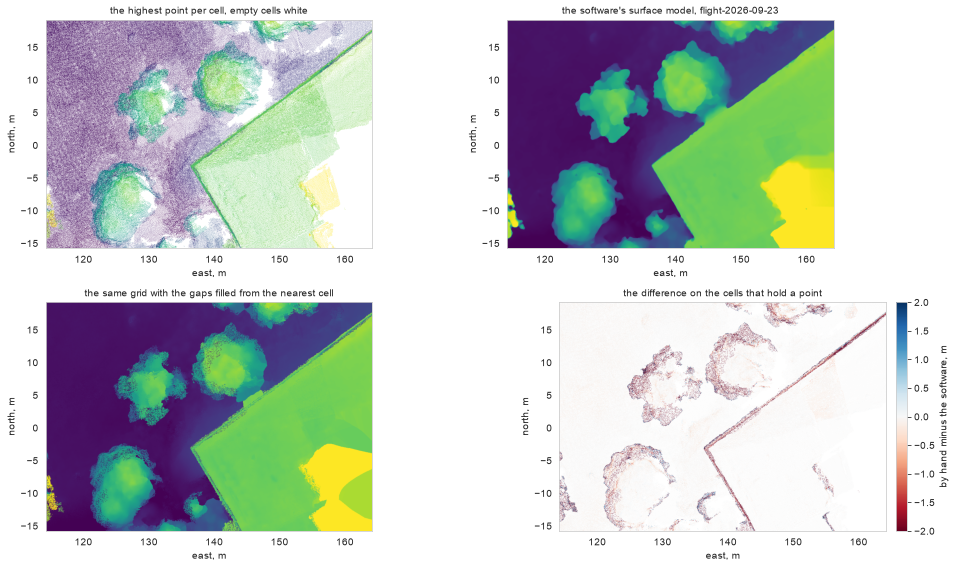

In [4]:
def grid_dsm(xyz, bounds, cell):
    # the highest point per cell of a grid over bounds (minx, miny, maxx, maxy), north up; cells no point reaches stay NaN
    minx, miny, maxx, maxy = bounds
    cols, rows = int(round((maxx - minx) / cell)), int(round((maxy - miny) / cell))
    c = np.floor((xyz[:, 0] - minx) / cell).astype(int); r = np.floor((maxy - xyz[:, 1]) / cell).astype(int)
    keep = (c >= 0) & (c < cols) & (r >= 0) & (r < rows)
    z = np.full((rows, cols), -np.inf, dtype=np.float32); n = np.zeros((rows, cols), dtype=np.int32)
    np.maximum.at(z, (r[keep], c[keep]), xyz[keep, 2].astype(np.float32)); np.add.at(n, (r[keep], c[keep]), 1)
    z[n == 0] = np.nan
    return z, n


def fill_gaps(grid):
    # every empty cell takes the value of its nearest filled cell
    mask = np.isnan(grid)
    if not mask.any():
        return grid.copy()
    idx = ndi.distance_transform_edt(mask, return_distances=False, return_indices=True)
    return grid[tuple(idx)]


grid, count = grid_dsm(xyz, bounds_local, cell_m)
both = np.isfinite(grid) & np.isfinite(dsm)
difference = (grid - dsm)[both]
filled = fill_gaps(grid)
g = d["gridding"]
print(f"{np.isfinite(grid).mean():.1%} of the cells hold at least one point, {count.max()} points in the fullest   reference {g['filled_share']:.1%}")
print(f"on those cells, against the software's surface model: median absolute difference {np.median(np.abs(difference)):.3f} m, 95th percentile {np.percentile(np.abs(difference), 95):.3f} m, RMS {np.sqrt((difference ** 2).mean()):.3f} m   reference {g['median_abs_vs_software_m']}, {g['p95_abs_vs_software_m']}, {g['rms_vs_software_m']}")
print(f"{(np.abs(difference) > 0.5).mean():.1%} of the filled cells differ from the software's by more than half a metre, and they carry {((difference ** 2) * (np.abs(difference) > 0.5)).sum() / (difference ** 2).sum():.1%} of the squared difference")
print(f"with the gaps filled from the nearest cell: median absolute difference {np.nanmedian(np.abs(filled - dsm)):.3f} m, RMS {np.sqrt(np.nanmean((filled - dsm) ** 2)):.3f} m over every cell")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].imshow(grid, extent=extent, cmap="viridis", vmin=lo, vmax=hi); axes[0, 0].set_title("the highest point per cell, empty cells white", fontsize=10)
axes[0, 1].imshow(dsm, extent=extent, cmap="viridis", vmin=lo, vmax=hi); axes[0, 1].set_title(f"the software's surface model, {flight['label']}", fontsize=10)
axes[1, 0].imshow(filled, extent=extent, cmap="viridis", vmin=lo, vmax=hi); axes[1, 0].set_title("the same grid with the gaps filled from the nearest cell", fontsize=10)
shown = axes[1, 1].imshow(np.where(both, grid - dsm, np.nan), extent=extent, cmap="RdBu", vmin=-2, vmax=2)
fig.colorbar(shown, ax=axes[1, 1], fraction=0.03, pad=0.02, label="by hand minus the software, m")
axes[1, 1].set_title("the difference on the cells that hold a point", fontsize=10)
for ax in axes.ravel():
    ax.set_xlabel("east, m"); ax.set_ylabel("north, m"); ax.grid(False)
fig.tight_layout()

Read the first line as a density. At this cell size only a fraction of the cells receive a point at all, which is the cloud's hundred and some points per square metre against the four hundred cells that a square metre holds, and a surface model at the software's resolution is therefore mostly interpolation whatever the recipe. Then read the second line in order, the median first. Where a cell holds a point, our highest point and the software's surface agree to about a centimetre, which says the software's recipe is the same as ours at heart. The 95th percentile and the RMS say something else: a few cells differ by metres, and the third line locates them by weight, a small share of the cells carrying almost all of the squared difference. On the pre-flight of 17 September the median was about a centimetre while the RMS was over a metre, and the difference panel shows where those cells are, along the roof's edge and the rims of the crowns, where the highest point in a cell can be a point on the wall, a leaf at the crown's edge or a stray that the depth maps disagreed on, and where the software's model, which filters its cells and smooths, does not follow the stray. The last line is the filled grid against the software's over every cell, and its RMS should be smaller than the RMS on the filled cells alone, because the nearest neighbour fill copies the ordinary cells far more often than the strays.

In the pictures, the top left is the raw recipe, a speckle of cells with points and white between them; the top right is the software's, continuous; the bottom left is our fill, which looks continuous too and is the same speckle copied outward; and the bottom right is where the two disagree, blue where we are lower and red where we are higher.

## The ground under it: a terrain model by hand

The terrain model is the surface model with everything standing on the ground removed and the ground filled in beneath. The software does this with a filter named SMRF, the simple morphological filter, and the idea fits in ten lines. A morphological opening of a surface with a window of a given size lowers every cell to the lowest value within that window and then raises it back as far as the neighbours allow, which flattens anything narrower than the window down to the ground around it and leaves anything wider alone. The filter opens the surface with a series of growing windows, and after each one it compares the surface with the opened surface: a cell that dropped by more than the slope times the window plus a threshold is something that stood on the ground, and it is marked as not ground. What remains is the ground, and where the ground was removed the opened surface stands in for it. The windows, the slope and the threshold below are the software's own, read from the reference:

windows of 1, 2, 4, 8, 12, 18 m, a slope of 0.15 and a threshold of 0.5 m
69.6% of the cells kept as ground   reference 69.6%
against the software's terrain model: median absolute difference 0.040 m, 95th percentile 3.148 m, RMS 1.861 m   reference 0.04, 3.148, 1.861
under the crowns, our ground sits a median of -0.126 m from the software's   reference -0.126
the largest thing the filter can remove is narrower than its largest window of 18 m; the window's terrain model reaches -73.84 m and its surface model -69.64 m


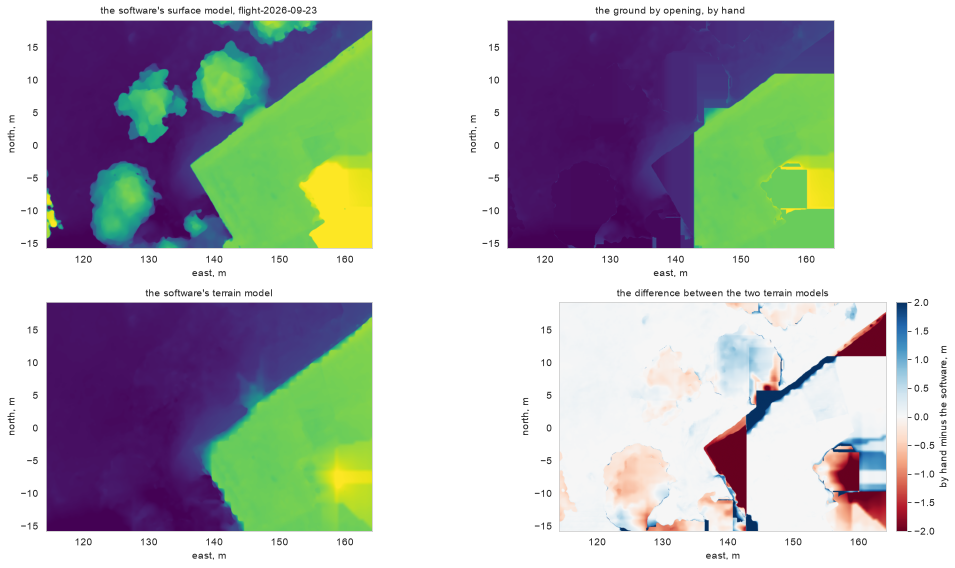

In [5]:
def ground_by_opening(dsm, cell, windows_m, slope, threshold):
    # a progressive morphological filter, the idea of SMRF: open with growing windows, drop what rises above the opened surface
    z = fill_gaps(np.asarray(dsm, dtype=np.float32))
    ground = np.ones(z.shape, dtype=bool)
    opened = z.copy()
    for w in windows_m:
        size = max(3, int(round(w / cell)) | 1)                                    # an odd number of cells
        new = ndi.grey_opening(opened, size=(size, size))
        ground &= (opened - new) <= slope * w + threshold                         # still ground if it did not drop by more than the rule allows
        opened = new
    return np.where(ground, z, opened), ground                                    # the surface where kept, the opened surface where not


h = d["ground_by_hand"]
ground_hand, is_ground = ground_by_opening(dsm, cell_m, h["windows_m"], h["slope"], h["threshold_m"])
height = dsm - dtm                                                                 # the software's height of things
crowns = np.nan_to_num(height) > 3.0                                               # where the software's own models say something stands 3 m or more over the terrain
gap = ground_hand - dtm
print(f"windows of {', '.join(str(w) for w in h['windows_m'])} m, a slope of {h['slope']} and a threshold of {h['threshold_m']} m")
print(f"{is_ground.mean():.1%} of the cells kept as ground   reference {h['ground_share']:.1%}")
print(f"against the software's terrain model: median absolute difference {np.nanmedian(np.abs(gap)):.3f} m, 95th percentile {np.nanpercentile(np.abs(gap), 95):.3f} m, RMS {np.sqrt(np.nanmean(gap ** 2)):.3f} m   reference {h['median_abs_vs_software_m']}, {h['p95_abs_vs_software_m']}, {h['rms_vs_software_m']}")
print(f"under the crowns, our ground sits a median of {np.nanmedian(gap[crowns]):+.3f} m from the software's   reference {h['under_crowns_median_m']:+}")
print(f"the largest thing the filter can remove is narrower than its largest window of {max(h['windows_m'])} m; the window's terrain model reaches {np.nanmax(dtm):.2f} m and its surface model {np.nanmax(dsm):.2f} m")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].imshow(dsm, extent=extent, cmap="viridis", vmin=lo, vmax=hi); axes[0, 0].set_title(f"the software's surface model, {flight['label']}", fontsize=10)
axes[0, 1].imshow(ground_hand, extent=extent, cmap="viridis", vmin=lo, vmax=hi); axes[0, 1].set_title("the ground by opening, by hand", fontsize=10)
axes[1, 0].imshow(dtm, extent=extent, cmap="viridis", vmin=lo, vmax=hi); axes[1, 0].set_title("the software's terrain model", fontsize=10)
shown = axes[1, 1].imshow(gap, extent=extent, cmap="RdBu", vmin=-2, vmax=2)
fig.colorbar(shown, ax=axes[1, 1], fraction=0.03, pad=0.02, label="by hand minus the software, m")
axes[1, 1].set_title("the difference between the two terrain models", fontsize=10)
for ax in axes.ravel():
    ax.set_xlabel("east, m"); ax.set_ylabel("north, m"); ax.grid(False)
fig.tight_layout()

The first line is the filter's recipe, and the second is what it decided: the share of the window it kept as ground. Read the third line the way you read the gridding: the median says the two terrain models agree to a centimetre over most of the window, and the 95th percentile and the RMS say that somewhere they part by metres. The difference panel says where. Look for a band along the roof's edge: the software builds its terrain by interpolating between the points its filter kept, so its terrain ramps from the lawn up onto the roof over several metres, while our opened surface stays at the lawn's level and steps up where the opening decided the roof began, and between the two lies a band of metres with one sign. The fourth line looks under the crowns, where neither model saw the ground and both invented it; ours is the opened surface, the lowest ground within the window that removed the crown, and the software's is an interpolation from the ground points around it, so a small offset with a sign is what to expect, and the sign tells you which of the two inventions is the lower.

The last line is the point of the section. Compare the three heights it prints. The filter removes anything narrower than its largest window, and the crowns are, so in the pictures they are gone from both terrain models, ours and the software's alike, and the lawn shows through where they stood. A flat roof wider than that window is not narrower than anything the filter tries, so the opening never lowers it, no cell of it ever drops by more than the rule allows, and the roof is kept as ground. Look for it in the two terrain models: if the roof is there, the terrain model's maximum stands near the roof's height and the height of things over the roof is zero, which is what 03b-05 noticed when it split the cloud by height. This is not a bug in the software or in our ten lines; it is what a morphological filter is, and the remedy is a larger window, which then flattens the real hills, or a terrain model from elsewhere, which is why 03-07 took the federal one.

## Hillshades, and the height of things

A raster of heights is read best as if a lamp stood over it. A hillshade lights every cell by the angle between its slope and a light from the north west at forty five degrees, and matplotlib's `LightSource` does it from the grid and the cell size. Shaded, the surface model shows its texture and the terrain model shows what the filter left, and their difference, cell by cell, is the height of things, the product 03-07 built from the terrain of another source:

the height of things over the window: median 0.04 m, 95th percentile 9.59 m, maximum 14.36 m   reference 0.04, 9.59, 14.36
24.8% of the window stands more than 3 m over the terrain model, 11.2% more than 8 m


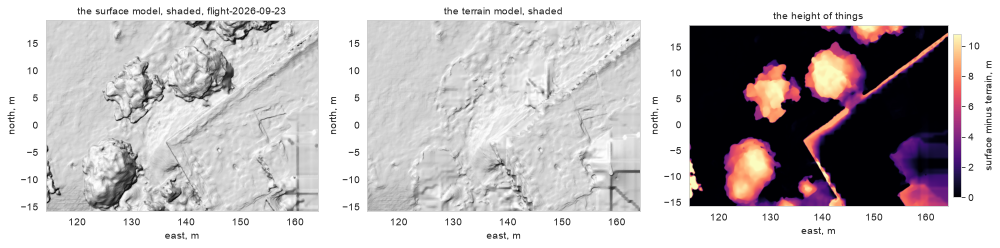

In [6]:
light = LightSource(azdeg=315, altdeg=45)
ground_level = float(np.nanpercentile(dsm, 25))
shade_dsm = light.hillshade(np.nan_to_num(dsm, nan=ground_level), vert_exag=1, dx=cell_m, dy=cell_m)
shade_dtm = light.hillshade(np.nan_to_num(dtm, nan=ground_level), vert_exag=1, dx=cell_m, dy=cell_m)
print(f"the height of things over the window: median {np.nanpercentile(height, 50):.2f} m, 95th percentile {np.nanpercentile(height, 95):.2f} m, maximum {np.nanmax(height):.2f} m   reference {d['height_p50_m']}, {d['height_p95_m']}, {d['height_max_m']}")
print(f"{(np.nan_to_num(height) > 3).mean():.1%} of the window stands more than 3 m over the terrain model, {(np.nan_to_num(height) > 8).mean():.1%} more than 8 m")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(shade_dsm, extent=extent, cmap="gray", vmin=0, vmax=1); axes[0].set_title(f"the surface model, shaded, {flight['label']}", fontsize=10)
axes[1].imshow(shade_dtm, extent=extent, cmap="gray", vmin=0, vmax=1); axes[1].set_title("the terrain model, shaded", fontsize=10)
shown = axes[2].imshow(height, extent=extent, cmap="magma", vmin=0, vmax=max(1.0, np.nanpercentile(height, 99)))
fig.colorbar(shown, ax=axes[2], fraction=0.03, pad=0.02, label="surface minus terrain, m")
axes[2].set_title("the height of things", fontsize=10)
for ax in axes:
    ax.set_xlabel("east, m"); ax.set_ylabel("north, m"); ax.grid(False)
fig.tight_layout()

The median of the height of things is about zero, because most of the window is lawn and path, and the 95th percentile and the maximum are the crowns and the tallest thing on the roof; print them beside the reference and read the second line for how much of the window stands up at all. In the shaded pictures, the surface model has the crowns as rough domes, the paths as faint ridges and the roof as a flat plate with a hard shadow along its edge; the terrain model has lost the domes and kept the plate, if the filter kept the roof, and the lawn's own gentle slope shows in both. The third picture is the difference, and it is where you check what the previous section said: the crowns are bright, the lawn is dark, and the roof's interior is whatever the terrain model made of it.

## Your turn

Measure the height of the flat roof by another route than 03-07's, which subtracted the federal terrain model. The surface model knows the roof and the terrain model here does not, so take the ground from beside the roof instead. Find the roof's cells as the tallest flat region of the surface model, the cells that stand 8 m or more above the window's ground level, which is the lower quarter of the surface model, and whose local gradient on a slightly smoothed surface is small, then keep the largest connected region of them. The roof's height is the median surface height on those cells minus the ground level. Print beside it what the surface minus the terrain says at the same cells, and say why the two are not the same number, and how yours compares with the building heights of 03-07.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [7]:
# Your attempt. dsm and dtm are the two models of the window, cell_m their cell size and ndi is scipy.ndimage.
#
# ground_level = np.nanpercentile(dsm, ___)                                              # the lower quarter of the surface model is the lawn and the paths
# smooth = ndi.uniform_filter(np.nan_to_num(dsm, nan=ground_level), int(round(0.5 / cell_m)) | 1)
# slope = np.hypot(*np.gradient(smooth, cell_m))                                        # the local gradient, metres per metre
# candidates = (smooth > ground_level + ___) & (slope < ___)                             # 8 m above the lawn, and flat
# labels, n = ndi.label(candidates)
# roof = labels == np.argmax(ndi.sum(candidates, labels, range(1, n + 1))) + 1           # the largest flat tall region is the roof
# print(f"the roof's top stands {np.nanmedian(dsm[roof]) - ground_level:.1f} m above the lawn beside it, over {roof.sum() * cell_m ** 2:.0f} square metres")
# print(f"the surface minus the terrain says {np.nanmedian((dsm - dtm)[roof]):.1f} m at the same cells")

## Check your understanding

1. The mesh was built in the plan alone, with the heights attached afterwards. Say what a two and a half dimensional mesh cannot represent, and name two things in a town that a drone block flown straight down would model wrongly because of it.
2. The surface model keeps the highest point in every cell. Say what that does to a tree crown at the cell size used here, and what it does to a thin thing like a lamp post or a fence, and which of the two the software's filtering would change.
3. A morphological opening removes what is narrower than its window and keeps what is wider. Say what that means for the flat roof in this window, for a single tree, and for a row of trees along a street whose crowns touch.
4. The terrain model is smooth where the surface model is rough. Say where its heights come from under a crown and under a roof, and why a terrain model can be wrong by metres in a place where the surface model is right to a centimetre.

## Where we are

You have turned the cloud into three surfaces by hand and set each beside the software's. The mesh by Delaunay showed you that a two and a half dimensional mesh is a triangulation of the plan with heights attached, and that the software's fewer triangles are a simplification that spends them where the surface bends. The surface model as the highest point per cell agreed with the software's to a centimetre where a point exists and by metres on a few cells at the edges, which is what filtering and gap filling are for. The terrain model by opening removed the crowns exactly as the software's filter did, and kept what was wider than its largest window, so that the height of things is right over the trees and wrong over the roof, and you know why.

The habit worth keeping: when a product looks smooth, ask what was thrown away to make it so and where, because a surface model hides the gaps it filled and a terrain model hides the roof it kept.

In 03b-07 a photograph is laid onto this surface.

## Further resources

Nothing in this course requires anything below.

The mesh the software builds for a full three dimensional model, rather than the two and a half dimensional one used here, is Poisson surface reconstruction, by Kazhdan, Bolitho and Hoppe: https://hhoppe.com/poissonrecon.pdf. The terrain filter is the simple morphological filter of Pingel, Clarke and McBride, An improved simple morphological filter for the terrain classification of airborne LIDAR data, ISPRS Journal of Photogrammetry and Remote Sensing 77, 2013, pages 21 to 30, which the software applies through PDAL. Szeliski's free textbook covers surfaces from points, meshes and their simplification in chapter 13: https://szeliski.org/Book/

OpenDroneMap's documentation describes its meshing options and its elevation models, their resolution, their gap filling and the terrain filter's parameters: https://docs.opendronemap.org/arguments/dem-resolution/ and https://docs.opendronemap.org/arguments/, and OpenSfM's documentation the reconstruction the products rest on: https://opensfm.org/docs/

The cloud, the mesh and the two models are the course's own flight, published under CC BY 4.0.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The roof's height from the surface model against the lawn beside it, and what the terrain model makes of the same cells, from the files themselves so that the cell stands on its own:

```python
import numpy as np
import rasterio
from scipy import ndimage as ndi

with rasterio.open("data/dsm_window.tif") as src:
    dsm = src.read(1, masked=True).filled(np.nan); cell_m = float(src.res[0])
with rasterio.open("data/dtm_window.tif") as src:
    dtm = src.read(1, masked=True).filled(np.nan)
ground_level = np.nanpercentile(dsm, 25)
smooth = ndi.uniform_filter(np.nan_to_num(dsm, nan=ground_level), int(round(0.5 / cell_m)) | 1)
slope = np.hypot(*np.gradient(smooth, cell_m))
candidates = (smooth > ground_level + 8) & (slope < 0.3)
labels, n = ndi.label(candidates)
roof = labels == np.argmax(ndi.sum(candidates, labels, range(1, n + 1))) + 1
print(f"the roof's top stands {np.nanmedian(dsm[roof]) - ground_level:.1f} m above the lawn beside it, over {roof.sum() * cell_m ** 2:.0f} square metres")
print(f"the surface minus the terrain says {np.nanmedian((dsm - dtm)[roof]):.1f} m at the same cells")
```

The two numbers differ because the terrain model under the roof is not the ground. Where the filter kept the roof, the terrain is the roof and the difference is zero; where the software's terrain ramps from the lawn up onto the roof, the difference is some part of the roof's height. 03-07 subtracted the federal terrain model, which knows nothing of the roof and so gives the roof its full height, at the price of the metre and a quarter of datum that 03-07 had to settle first.